# Autograd - Build
This is the build section of the project, where new functions, classes, etc are created and tested. Finished peices are moved into main where they are then called and used by build.

### Rules:
- No ai used to generate any code, only for reaserch, explinations and code reviews
- Finished peices must be abstract and state clearly if any cases are not covered

## Setup

In [1]:
import numpy as np
import main
from typing import Union, List
from matplotlib import pyplot as plt
import matplotlib_inline
%matplotlib

Using matplotlib backend: module://matplotlib_inline.backend_inline


## Build

### Simple linerar fitting

Epoch 1 - Mean error -18.81699986338615
Epoch 10 - Mean error -2.0367425513267507
Epoch 20 - Mean error -1.937384384870528
Epoch 30 - Mean error -1.8433331871032703
Epoch 40 - Mean error -1.7538474297523488
Epoch 50 - Mean error -1.668706681728362
Epoch 60 - Mean error -1.5876971602439869
Epoch 70 - Mean error -1.5106216645240773
Epoch 80 - Mean error -1.4372876453399648
Epoch 90 - Mean error -1.3675147199630726
Epoch 100 - Mean error -1.3011283826827997


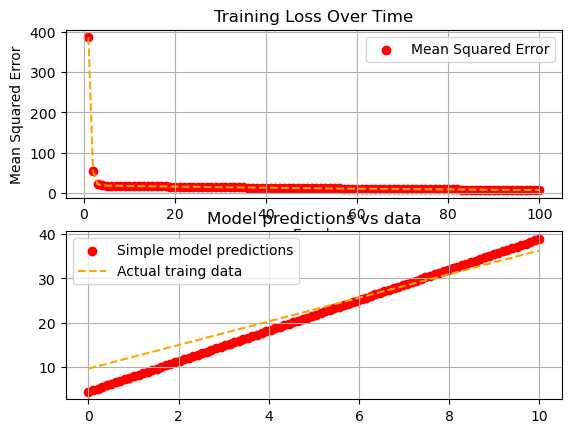

In [26]:
x_axis_for_data = np.linspace(0, 10, 100)
inputs = np.asarray(np.split(x_axis_for_data, 100))
targets = inputs * 2.67 + 9.6

Simple = main.LinearLayer(input_size=1, output_size=1, precision='float32')

mse_over_time = []
time = np.linspace(1, 100, 100)

for i in range(100):
    x = Simple.forward(inputs)
    error = x - targets
    mse_over_time.append(np.mean(error ** 2.0))

    if (i+1) % 10 == 0 or i == 0:
        print(f"Epoch {i+1} - Mean error {np.mean(error)}")

    #Gradient of loss with respect to output for MSE
    error_grad = (2.0 / inputs.shape[0]) * error

    Simple.backwards(error_grad)
    Simple.update_parameters(0.01)

model_preds = Simple.forward(inputs)

fig , axs = plt.subplots(2)

axs[0].scatter(x=time, y=mse_over_time, color='red', label='Mean Squared Error')
axs[0].plot(time, mse_over_time, color='orange', linestyle='--')

axs[0].set_title("Training Loss Over Time")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Mean Squared Error")
axs[0].grid(True)
axs[0].legend()


axs[1].scatter(x=x_axis_for_data, y=model_preds, color='red', label='Simple model predictions')
axs[1].plot(x_axis_for_data,  targets.flatten(), color='orange', linestyle='--', label='Actual traing data')

axs[1].set_title("Model predictions vs data")
axs[1].grid(True)
axs[1].legend()



plt.show()